# 01. Pembagian Data

Proyek ini bertujuan memprediksi arah kurs USD/IDR pada hari perdagangan berikutnya (naik atau turun)
dengan memanfaatkan berita geopolitik.

Notebook ini menyiapkan data dasar untuk seluruh tahap berikutnya:
1. Membentuk target, yaitu arah kurs pada hari perdagangan berikutnya.
2. Membentuk fitur harga dari pergerakan kurs sebelumnya.
3. Membagi data secara berurutan menurut waktu menjadi tiga bagian:
   - train: data untuk melatih model,
   - validation: data untuk memilih pengaturan model terbaik,
   - test: data untuk pengujian akhir.

Data masukan berasal dari folder `data/processed/`. Hasil notebook ini disimpan di folder `data/`.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("../data") if Path("../data").exists() else Path("data")  # berjalan dari folder notebook atau folder utama repo
PROC = DATA / "processed"      # data hasil preprocessing

TRAIN_FRAC, VAL_FRAC = 0.70, 0.15  # sisa 0.15 untuk test
WARMUP = 20                        # 20 hari awal tidak digunakan (fitur 20 hari belum lengkap)
EMBARGO = 1                        # 1 hari dihapus di setiap batas pembagian (embargo)

## 1. Memuat Data Kurs

In [10]:
df = pd.read_csv(PROC / "aligned_dataset.csv", usecols=["date", "usd_idr", "jumlah_berita"], parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"{len(df)} hari trading, {df.date.min().date()} s.d. {df.date.max().date()}")

1202 hari trading, 2021-09-01 s.d. 2026-09-01


## 2. Membentuk Target
Target terdiri atas dua kelas:
- `1` (NAIK): kurs hari berikutnya lebih tinggi daripada hari ini, artinya rupiah melemah.
- `0` (TURUN/TETAP): kurs hari berikutnya sama atau lebih rendah, artinya rupiah menguat atau stabil.

Kolom `target_ret` juga disimpan. Kolom ini berisi perubahan kurs hari berikutnya dalam bentuk log-return
dan digunakan oleh model ARIMA.

In [11]:
df["log_price"] = np.log(df["usd_idr"])
df["target_ret"] = df["log_price"].shift(-1) - df["log_price"]
df["target"] = (df["usd_idr"].shift(-1) > df["usd_idr"]).astype(float)
df.loc[df["target_ret"].isna(), "target"] = np.nan  # hari terakhir tidak memiliki kurs hari berikutnya

print("Hari dengan kurs tetap:", int((df["target_ret"] == 0).sum()))
print(df["target"].value_counts(normalize=True).rename({1.0: "NAIK", 0.0: "TURUN/TETAP"}).round(3))

Hari dengan kurs tetap: 13
target
NAIK           0.554
TURUN/TETAP    0.446
Name: proportion, dtype: float64


## 3. Membentuk Fitur Harga
Fitur adalah informasi yang diberikan kepada model untuk membuat prediksi. Seluruh fitur di bawah hanya
menggunakan data kurs sampai hari ini.

| Fitur | Keterangan |
|---|---|
| `ret_1` | perubahan kurs hari ini |
| `ret_lag1` s.d. `ret_lag4` | perubahan kurs 1 sampai 4 hari sebelumnya |
| `ret_5`, `ret_20` | total perubahan kurs selama 5 dan 20 hari terakhir |
| `vol_5`, `vol_20` | volatilitas (besarnya fluktuasi) kurs selama 5 dan 20 hari terakhir |
| `z_20` | posisi kurs hari ini terhadap rata-rata 20 hari terakhir |
| `gap_days` | jumlah hari sejak hari perdagangan sebelumnya, misalnya setelah libur |

Sebanyak 20 hari pertama tidak digunakan karena belum memiliki data 20 hari sebelumnya.

In [12]:
r = df["log_price"].diff()
df["ret_1"] = r
for k in range(1, 5):
    df[f"ret_lag{k}"] = r.shift(k)
df["ret_5"] = df["log_price"].diff(5)
df["ret_20"] = df["log_price"].diff(20)
df["vol_5"] = r.rolling(5).std()
df["vol_20"] = r.rolling(20).std()
df["z_20"] = (df["usd_idr"] - df["usd_idr"].rolling(20).mean()) / df["usd_idr"].rolling(20).std()
df["gap_days"] = df["date"].diff().dt.days

PRICE_FEATURES = ["ret_1", "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4",
                  "ret_5", "ret_20", "vol_5", "vol_20", "z_20", "gap_days"]

data = df.iloc[WARMUP:].dropna(subset=PRICE_FEATURES + ["target"]).reset_index(drop=True)
data["target"] = data["target"].astype(int)
print(f"Data siap pakai: {len(data)} hari")

Data siap pakai: 1181 hari


## 4. Membagi Data Berdasarkan Urutan Waktu
Data tidak diacak karena model hanya dapat belajar dari masa lalu.
Pembagiannya adalah train 70% (periode awal), validation 15%, dan test 15% (periode akhir).

Satu hari di setiap batas pembagian dihapus (embargo). Target hari terakhir train dihitung dari kurs hari pertama
validation, sehingga tanpa embargo sebagian informasi validation akan ikut masuk ke data latih (data leakage).

In [13]:
n = len(data)
i_tr, i_va = int(n * TRAIN_FRAC), int(n * (TRAIN_FRAC + VAL_FRAC))
splits = {
    "train": data.iloc[: i_tr - EMBARGO].copy(),
    "val": data.iloc[i_tr: i_va - EMBARGO].copy(),
    "test": data.iloc[i_va:].copy(),
}

# Pemeriksaan: tanggal antarbagian tidak boleh tumpang tindih
assert splits["train"].date.max() < splits["val"].date.min()
assert splits["val"].date.max() < splits["test"].date.min()

pd.DataFrame({
    "jumlah_hari": {k: len(v) for k, v in splits.items()},
    "mulai": {k: v.date.min().date() for k, v in splits.items()},
    "selesai": {k: v.date.max().date() for k, v in splits.items()},
    "proporsi_NAIK": {k: round(v.target.mean(), 3) for k, v in splits.items()},
})

,jumlah_hari,mulai,selesai,proporsi_NAIK
train,825,2021-09-29,2025-02-24,0.558
val,176,2025-02-26,2025-11-24,0.517
test,178,2025-11-26,2026-08-31,0.579


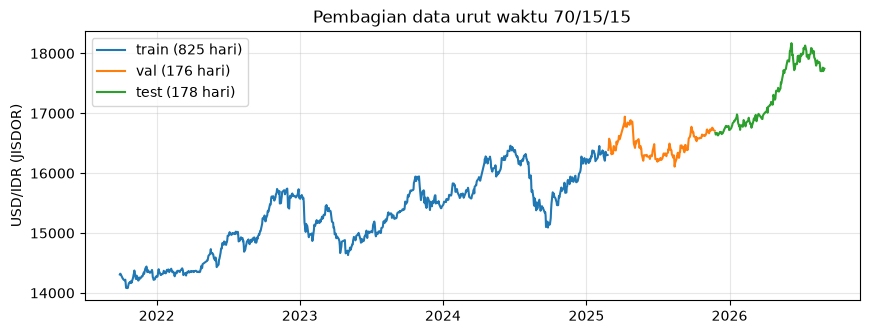

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for name, part in splits.items():
    ax.plot(part.date, part.usd_idr, label=f"{name} ({len(part)} hari)")
ax.set_ylabel("USD/IDR (JISDOR)")
ax.set_title("Pembagian data urut waktu 70/15/15")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 5. Menentukan Hari Perdagangan untuk Setiap Berita
Setiap berita dipasangkan dengan hari perdagangan menggunakan aturan yang sama seperti pada `aligned_dataset.csv`:
- waktu terbit dikonversi dari UTC ke WIB,
- berita yang terbit setelah pukul 16.00 WIB dihitung untuk hari berikutnya, karena kurs JISDOR hari itu sudah terbentuk,
- berita yang terbit pada hari libur dipindahkan ke hari perdagangan berikutnya.

In [15]:
art = pd.read_csv(PROC / "articles_clean.csv", parse_dates=["published_at"],
                  usecols=["published_at", "clean_title", "lead_paragraph", "clean_content"])
kurs = pd.read_csv(PROC / "jisdor_usd_idr.csv", parse_dates=["date"])
trading_days = pd.DatetimeIndex(kurs["date"].sort_values().unique())

wib = art["published_at"].dt.tz_localize("UTC").dt.tz_convert("Asia/Jakarta")
tanggal = wib.dt.tz_localize(None).dt.normalize() + pd.to_timedelta((wib.dt.hour >= 16).astype(int), unit="D")
pos = trading_days.searchsorted(tanggal.values)  # hari perdagangan pertama yang >= tanggal
art["date"] = [trading_days[p] if p < len(trading_days) else pd.NaT for p in pos]

# Pemeriksaan: jumlah berita per hari harus sama dengan aligned_dataset.csv
aligned = pd.read_csv(PROC / "aligned_dataset.csv", usecols=["date", "jumlah_berita"], parse_dates=["date"])
hitung = art.groupby("date").size().reindex(aligned["date"]).fillna(0).values
print("Sama dengan aligned_dataset.csv:", bool((hitung == aligned["jumlah_berita"].values).all()))

Sama dengan aligned_dataset.csv: True


## 6. Menyimpan Hasil
- `train.csv`, `val.csv`, `test.csv`: setiap baris berisi satu hari perdagangan.
- Folder `articles/`: teks berita per artikel beserta tanggal dan label bagiannya (train, val, atau test).
  Berita pada bagian train disimpan dalam dua file agar ukuran setiap file tidak terlalu besar.

In [16]:
KOLOM = ["date", "usd_idr", "target", "target_ret"] + PRICE_FEATURES + ["jumlah_berita"]
label = {}
for name, part in splits.items():
    part[KOLOM].to_csv(DATA / f"{name}.csv", index=False, date_format="%Y-%m-%d")
    label.update({d: name for d in part["date"]})

art["split"] = art["date"].map(label)
art = art.dropna(subset=["split"]).rename(columns={"clean_title": "title", "lead_paragraph": "lead",
                                                   "clean_content": "content"})
art = art[["date", "split", "title", "lead", "content"]].fillna("").sort_values("date")

# Disimpan per bagian; data train dibagi menjadi 2 file agar ukurannya tidak terlalu besar
(DATA / "articles").mkdir(exist_ok=True)
train_art = art[art.split == "train"]
half = len(train_art) // 2
parts = {"articles_train_1": train_art.iloc[:half], "articles_train_2": train_art.iloc[half:],
         "articles_val": art[art.split == "val"], "articles_test": art[art.split == "test"]}
for name, part in parts.items():
    part.to_csv(DATA / "articles" / f"{name}.csv", index=False, date_format="%Y-%m-%d")
    print(f"{name}.csv: {len(part)} artikel")

articles_train_1.csv: 4614 artikel
articles_train_2.csv: 4614 artikel
articles_val.csv: 2278 artikel
articles_test.csv: 2707 artikel
